# House Price Prediction — 4. Predictions & Visualization

Visual evaluation of the best model: predicted vs actual prices, residual analysis, and error breakdown by price range.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')

preds = pd.read_csv('../data/processed/predictions.csv')
comparison = pd.read_csv('../data/processed/model_comparison.csv', index_col=0)
best_model_name = joblib.load('../data/processed/best_model_name.pkl')

col_map = {
    'Linear Regression': 'linear_regression_pred',
    'Random Forest': 'random_forest_pred',
    'XGBoost': 'xgboost_pred'
}
best_col = col_map[best_model_name]
print('Best model:', best_model_name)
preds.head()

Best model: Random Forest


,actual_price,linear_regression_pred,random_forest_pred,xgboost_pred
0,2350000,5.690338e+06,2.694023e+06,3443105.5
1,25000000,2.108673e+07,3.031441e+07,32867748.0
2,5500000,8.151944e+06,6.940658e+06,6722072.5
3,18000000,1.760722e+07,1.841258e+07,17575532.0
4,37000000,4.035899e+07,4.172308e+07,40155510.0


## 1. Predicted vs Actual Price (scatter)

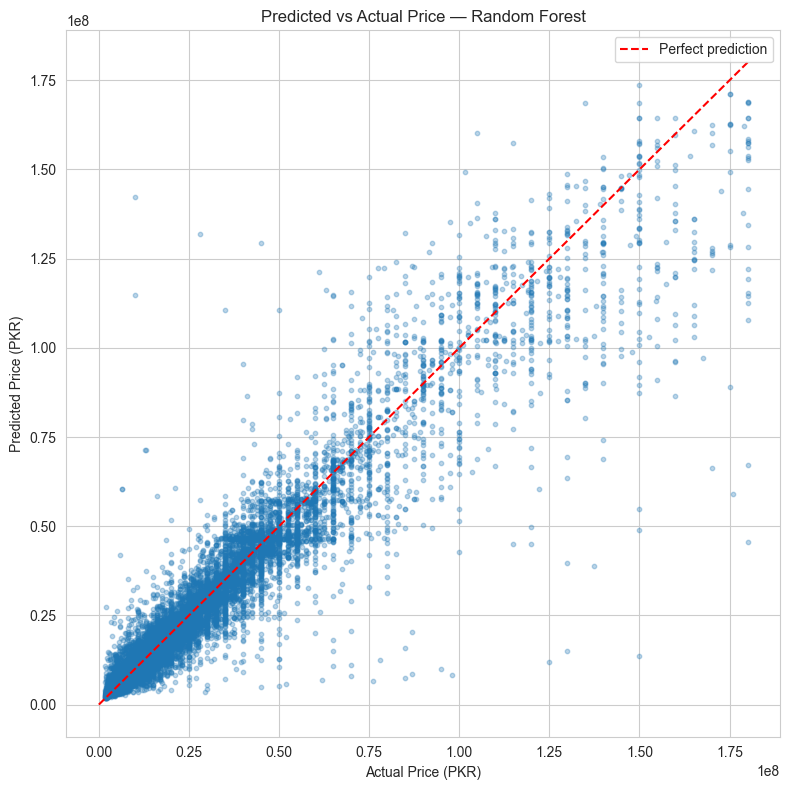

In [3]:
plt.figure(figsize=(8,8))
plt.scatter(preds['actual_price'], preds[best_col], alpha=0.3, s=10)
max_val = max(preds['actual_price'].max(), preds[best_col].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (PKR)')
plt.ylabel('Predicted Price (PKR)')
plt.title(f'Predicted vs Actual Price — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

Points close to the red dashed line are accurate predictions. The spread widening at higher prices is typical — very expensive, unusual properties are inherently harder to price precisely.

## 2. All Models Side-by-Side

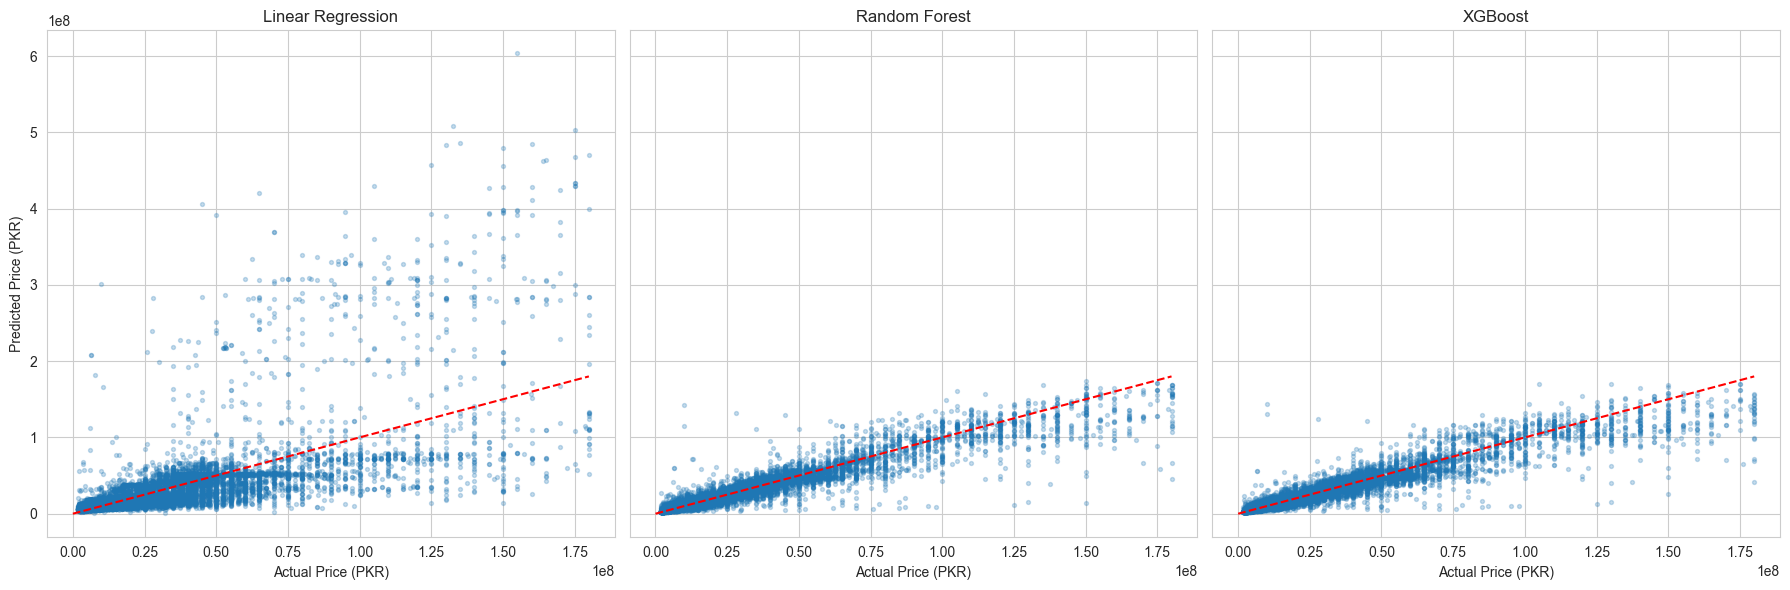

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharex=True, sharey=True)
for ax, (name, col) in zip(axes, col_map.items()):
    ax.scatter(preds['actual_price'], preds[col], alpha=0.25, s=8)
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Actual Price (PKR)')
axes[0].set_ylabel('Predicted Price (PKR)')
plt.tight_layout()
plt.show()

## 3. Residual Analysis

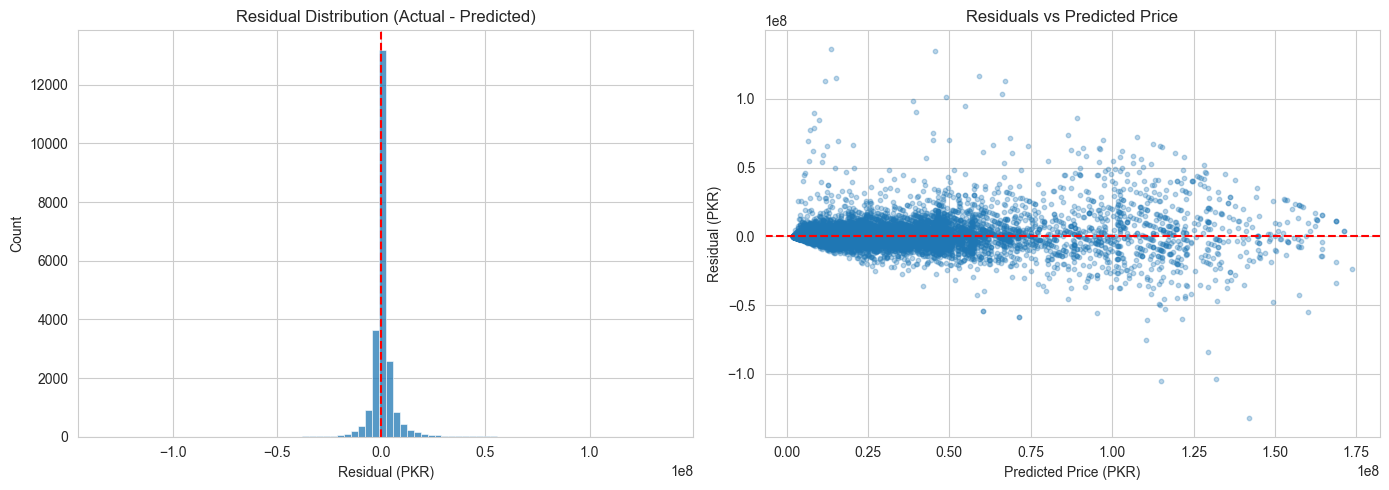

In [5]:
preds['residual'] = preds['actual_price'] - preds[best_col]
preds['pct_error'] = 100 * preds['residual'] / preds['actual_price']

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(preds['residual'], bins=80, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (Actual - Predicted)')
axes[0].set_xlabel('Residual (PKR)')

axes[1].scatter(preds[best_col], preds['residual'], alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted Price')
axes[1].set_xlabel('Predicted Price (PKR)')
axes[1].set_ylabel('Residual (PKR)')
plt.tight_layout()
plt.show()

## 4. Error by Price Range
Does the model perform equally well on cheap vs expensive properties?

In [6]:
preds['price_band'] = pd.qcut(preds['actual_price'], q=5,
    labels=['Lowest 20%', 'Low-Mid 20%', 'Mid 20%', 'Mid-High 20%', 'Highest 20%'])

band_error = preds.groupby('price_band', observed=True).apply(
    lambda d: pd.Series({
        'MAE': np.mean(np.abs(d['residual'])),
        'MAPE (%)': np.mean(np.abs(d['pct_error'])),
        'avg_actual_price': d['actual_price'].mean()
    })
)
band_error

C:\Users\EliteBook\AppData\Local\Temp\ipykernel_18156\3642302657.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  band_error = preds.groupby('price_band', observed=True).apply(


,MAE,MAPE (%),avg_actual_price
price_band,,,
Lowest 20%,1.031166e+06,24.432187,4.654625e+06
Low-Mid 20%,1.425879e+06,16.222869,8.794408e+06
Mid 20%,1.764664e+06,12.733554,1.379296e+07
Mid-High 20%,2.938832e+06,12.983220,2.250047e+07
Highest 20%,9.242769e+06,14.702493,6.051924e+07


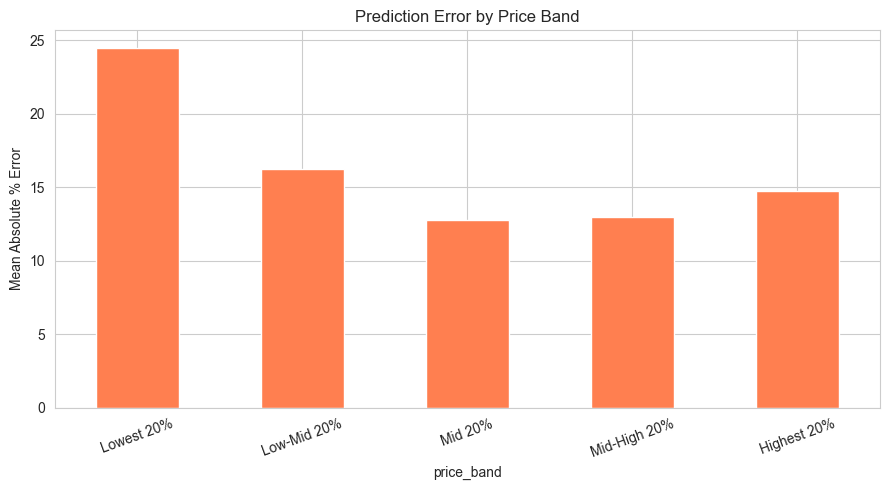

In [7]:
fig, ax1 = plt.subplots(figsize=(9,5))
band_error['MAPE (%)'].plot(kind='bar', ax=ax1, color='coral')
ax1.set_ylabel('Mean Absolute % Error')
ax1.set_title('Prediction Error by Price Band')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Lower-priced properties typically show a higher *percentage* error (small absolute mistakes are a bigger fraction of a smaller price), while higher-priced properties tend to have larger *absolute* errors but lower percentage error — a normal pattern in real estate pricing models.

## 5. Sample Predictions Table

In [8]:
sample = preds[['actual_price', best_col, 'residual', 'pct_error']].sample(15, random_state=1).copy()
sample.columns = ['Actual Price', 'Predicted Price', 'Residual', '% Error']
sample = sample.round(0)
sample

,Actual Price,Predicted Price,Residual,% Error
14381,40000000,49960323.0,-9960323.0,-25.0
12819,5000000,5607644.0,-607644.0,-12.0
11434,23500000,23434001.0,65999.0,0.0
10930,25000000,23594330.0,1405670.0,6.0
21866,17000000,16360876.0,639124.0,4.0
23031,7000000,7324643.0,-324643.0,-5.0
19763,6000000,6014190.0,-14190.0,-0.0
11978,3400000,3267905.0,132095.0,4.0
16746,15000000,14405811.0,594189.0,4.0
8319,8500000,5974204.0,2525796.0,30.0


## 6. Final Model Comparison Summary

In [9]:
comparison.style.format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.4f}'}).highlight_min(subset=['MAE','RMSE'], color='lightgreen').highlight_max(subset=['R2'], color='lightgreen')

,MAE,RMSE,R2
Random Forest,"3,253,167","7,330,911",0.9111
XGBoost,"3,563,942","7,600,896",0.9044
Linear Regression,"9,349,664","25,670,662",-0.0899


## Conclusion

- **Best model:** the table/plots above identify the strongest performer by RMSE/MAE/R².
- Tree-based ensembles (Random Forest / XGBoost) substantially outperform plain Linear Regression, since house prices depend on non-linear interactions between location, area, and property type.
- The model explains the large majority of price variance, with errors concentrated in unusual/extreme-priced properties — a realistic limitation given the data only includes structured fields (no condition, finishing quality, or recency of renovation, all of which affect real prices but aren't in the dataset).
- Artifacts saved: trained model (`best_model.pkl`), feature list, predictions, and metrics — ready to be wrapped in a web app for interactive predictions later.